# **GTSRB Traffic-Sign Recognition and Classification**

# **Problem Statement**

Traffic signs provide important information to drivers and help maintain road safety. However, manually identifying traffic signs from images can be difficult, especially in poor lighting, at high speeds, or in complex road environments.

# **Objective**

The objective of this project is to develop an automated Traffic Sign Recognition System that can identify and classify traffic signs from input images. The project uses OpenCV for image preprocessing and feature extraction, followed by machine learning techniques for accurate traffic sign classification.

# **Importing the Dataset**

In [ ]:
# Import required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# import the dataste
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/Train"

In [ ]:
classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Classes:", classes)
print("\nNumber of classes:", len(classes))

Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']

Number of classes: 43


In [ ]:
# load images
# List to store images and Labels
images = []
labels = []

# Read images from each class folder
for label in classes:
  class_path = os.path.join(dataset_path, label)

  for file_name in os.listdir(class_path):
    img_path = os.path.join(class_path, file_name)

    image = cv2.imread(img_path)

    if image is not None:
      images.append(image)
      labels.append(int(label))

print("Images loaded successfully!")

print("Total Images:", len(images))
print("Total Labels:", len(labels))
print("Number of Classes:", len(np.unique(labels)))

Images loaded successfully!
Total Images: 39262
Total Labels: 39262
Number of Classes: 43


In [ ]:
print("Image data type:", type(images[0]))
print("Label data type:", type(labels[0]))

Image data type: <class 'numpy.ndarray'>
Label data type: <class 'int'>


In [ ]:
# check image shape
print("First image shape:", images[0].shape)
print("First image labels:", labels[0])

First image shape: (30, 29, 3)
First image labels: 0


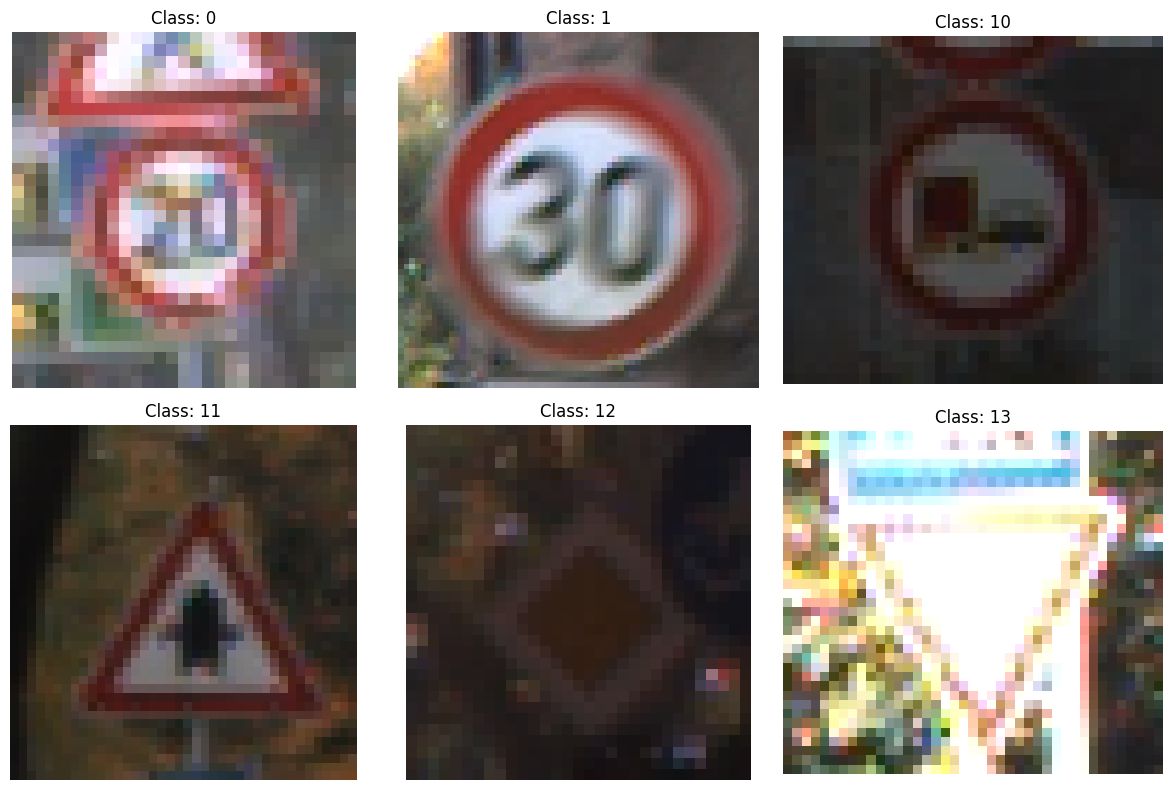

In [ ]:
# Display sample images
plt.figure(figsize = (12,8))

for i, cls in enumerate(classes[:6]):
  class_path = os.path.join(dataset_path, cls)

  img_name = os.listdir(class_path)[0]
  img_path = os.path.join(class_path, img_name)

  image = cv2.imread(img_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  plt.subplot(2,3, i+1)
  plt.imshow(image)
  plt.title(f"Class: {cls}")
  plt.axis("off")
plt.tight_layout()
plt.show()



In [ ]:
# Display image dimensions
print("\n========== IMAGE DIMENSIONS ==========")
for i in range(10):
    height, width, channels = images[i].shape


    print(
        f"Image {i+1}: "
        f"Height={height}, "
        f"Width={width}, "
        f"Channels={channels}"
    )


========== IMAGE DIMENSIONS ==========
Image 1: Height=30, Width=29, Channels=3
Image 2: Height=31, Width=31, Channels=3
Image 3: Height=32, Width=30, Channels=3
Image 4: Height=30, Width=30, Channels=3
Image 5: Height=30, Width=30, Channels=3
Image 6: Height=110, Width=108, Channels=3
Image 7: Height=58, Width=59, Channels=3
Image 8: Height=38, Width=37, Channels=3
Image 9: Height=76, Width=76, Channels=3
Image 10: Height=49, Width=49, Channels=3


In [ ]:
# Display number of classes

print("Classes:", classes)
print("Total Number of classes:", len(classes))

Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Total Number of classes: 43


# **Dataset Exploration(EDA)**

In [ ]:
# Number of Images
print("Number of Images:", len(images))

Number of Images: 39262


In [ ]:
# Number of classes
print("Number of classes:", len(classes))

Number of classes: 43


In [ ]:
# Check image resolutions

image_sizes = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        image = cv2.imread(img_path)

        if image is not None:
            height, width = image.shape[:2]
            image_sizes.append((width, height))

print("Total images:", len(image_sizes))
print("Unique resolution:", len(set(image_sizes)))
print("First 10 image resolutions:", image_sizes[:10])

Total images: 39262
Unique resolution: 2924
First 10 image resolutions: [(29, 30), (31, 31), (30, 32), (30, 30), (30, 30), (108, 110), (59, 58), (37, 38), (76, 76), (49, 49)]


In [ ]:
# check image format

image_formats = os.path.splitext(img_name)[1].lower()
print("Image formats:", image_formats)

Image formats: .png


In [ ]:
# Display number of classes

print("Class Labels:", classes)

Class Labels: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


**Class Distribution**

In [ ]:
# Number of images per class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

# create dataframe
class_distribution = pd.DataFrame(class_counts.items(),
                                  columns = ["Class Label", "Number of Images"])

# Sort class labels numerically
class_distribution["Class Label"] = class_distribution["Class Label"].astype(int)

class_distribution = class_distribution.sort_values(
    by="Class Label"
).reset_index(drop=True)


In [ ]:
# percent distribution

total_images = len(labels)
class_distribution["Percentage"] = (class_distribution["Number of Images"] / total_images * 100).round(2)
class_distribution

print("Total images from labels:", total_images)
print("Total images from class distribution:",
      class_distribution["Number of Images"].sum())

Total images from labels: 39262
Total images from class distribution: 39262


Image Analysis

In [ ]:
# 1.Image height
heights = []

for image in images:
  height = image.shape[0]
  heights.append(height)

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))
print("Average Height:", np.mean(heights))

Minimum Height: 25
Maximum Height: 225
Average Height: 50.33462380928124


In [ ]:
# 2.Image Width
widths = []

for image in images:
  width = image.shape[0]
  widths.append(width)

print("Minimum Widht:", min(widths))
print("Maximum Width:", max(widths))
print("Average Width:", np.mean(widths))

Minimum Widht: 25
Maximum Width: 225
Average Width: 50.33462380928124


In [ ]:
# Read one sample image
sample_class = sorted(classes)[0]
sample_image = os.listdir(os.path.join(dataset_path, sample_class))[0]

img_path = os.path.join(dataset_path, sample_class, sample_image)
image = cv2.imread(img_path)

print("Image Shape:", image.shape)
print("Image Height:", image.shape[0], "pixels")
print("Image Width:", image.shape[1], "pixels")
print("Color Channels:", image.shape[2])

Image Shape: (30, 29, 3)
Image Height: 30 pixels
Image Width: 29 pixels
Color Channels: 3


In [ ]:
# 3.Color channels
if len(image.shape) == 3:
    print("Image Type: color(3 Channels - BGR)")
else:
  print("Image Type: Grayscale (1 Channel)")

Image Type: color(3 Channels - BGR)


In [ ]:
# 4.RGB/Grayscale

# As we know, the dataset images are loaded as color images,
# so they have 3 color channels: RGB.



In [ ]:
# 5.Image Quality

# Check image Brightness
brightness = []

for image in images:
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  brightness.append(np.mean(gray))
print("Minimum brightness:", min(brightness))
print("maximum brightness:", max(brightness))
print("Average brightness:", np.mean(brightness))

Minimum brightness: 6.202022777494475
maximum brightness: 248.44000933706815
Average brightness: 81.98771001222468


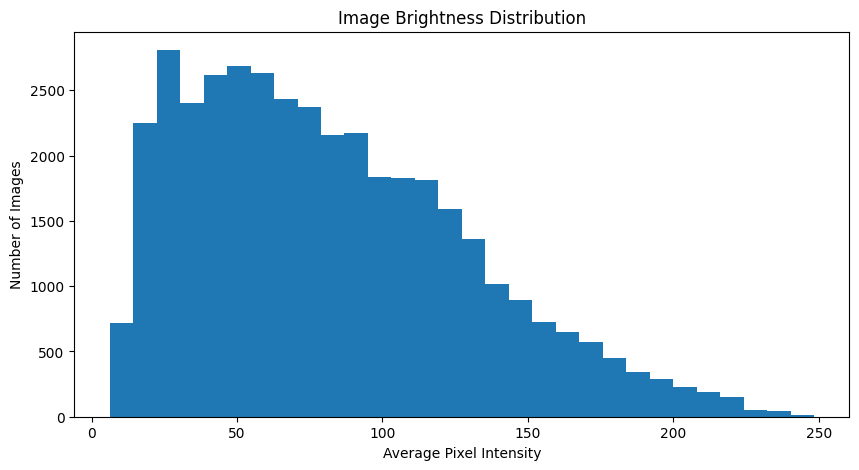

In [ ]:
# plot
plt.figure(figsize=(10, 5))
plt.hist(brightness, bins=30)
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Image Brightness Distribution")
plt.show()

In [ ]:
# check image sharpness
sharpness = []

for image in images:
   gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

   variance = cv2.Laplacian(gray, cv2.CV_64F).var()
   sharpness.append(variance)

print("Minimum sharpness:", min(sharpness))
print("Maximum sharpness:", max(sharpness))
print("Average sharpness:", np.mean(sharpness))

# Laplacian varince ->it is a method used to measure the sharpness or blurriness of an image.

Minimum sharpness: 6.947283143746249
Maximum sharpness: 17327.72987904
Average sharpness: 1596.0463852852629


**Observation**
- The dataset shows wide variation in brightness and sharpness.
- Average brightness is 81.99, ranging from 6.20 to 248.44, which means the set includes both very dark and very bright images.
- Average sharpness is 1596.05, with values between 6.95 and 17,327.73, indicating that most images contain useful edge information, though some are noticeably blurry.
- To ensure consistency before model training, preprocessing steps such as resizing, grayscale conversion, normalization, and HOG feature extraction will be applied.


# **Visual Analysis**

**Univariate Analysis**

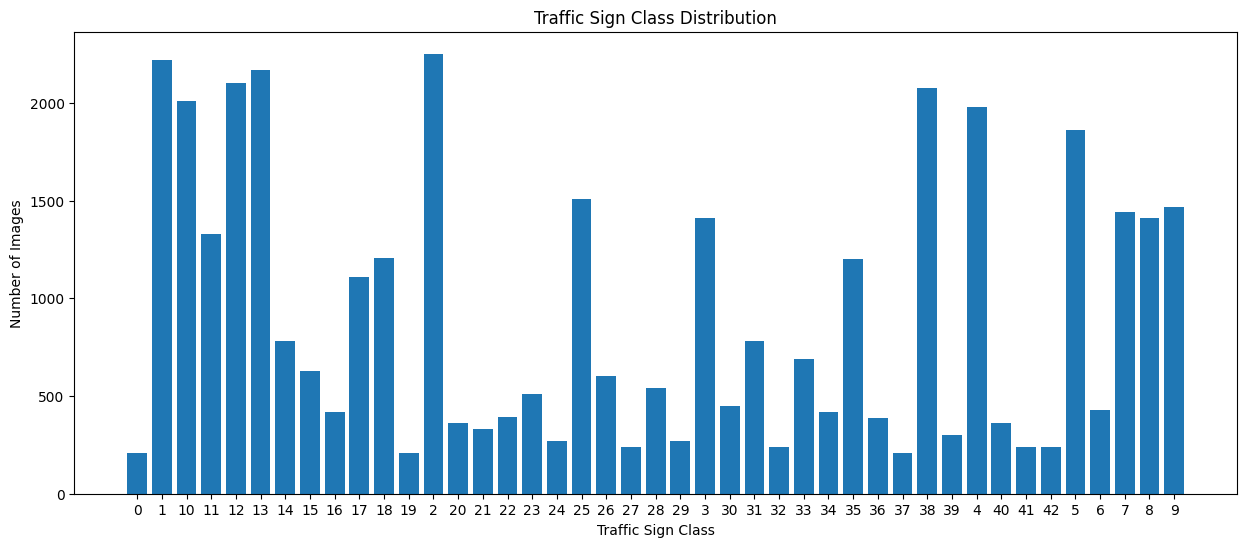

In [ ]:
# Class count plot

class_counts = {}

for cls in sorted(classes):
  class_path = os.path.join(dataset_path, cls)
  class_counts[cls] = len(os.listdir(class_path))
# plot
plt.figure(figsize=(15, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Traffic Sign Class")
plt.ylabel("Number of Images")
plt.title("Traffic Sign Class Distribution")
plt.show()

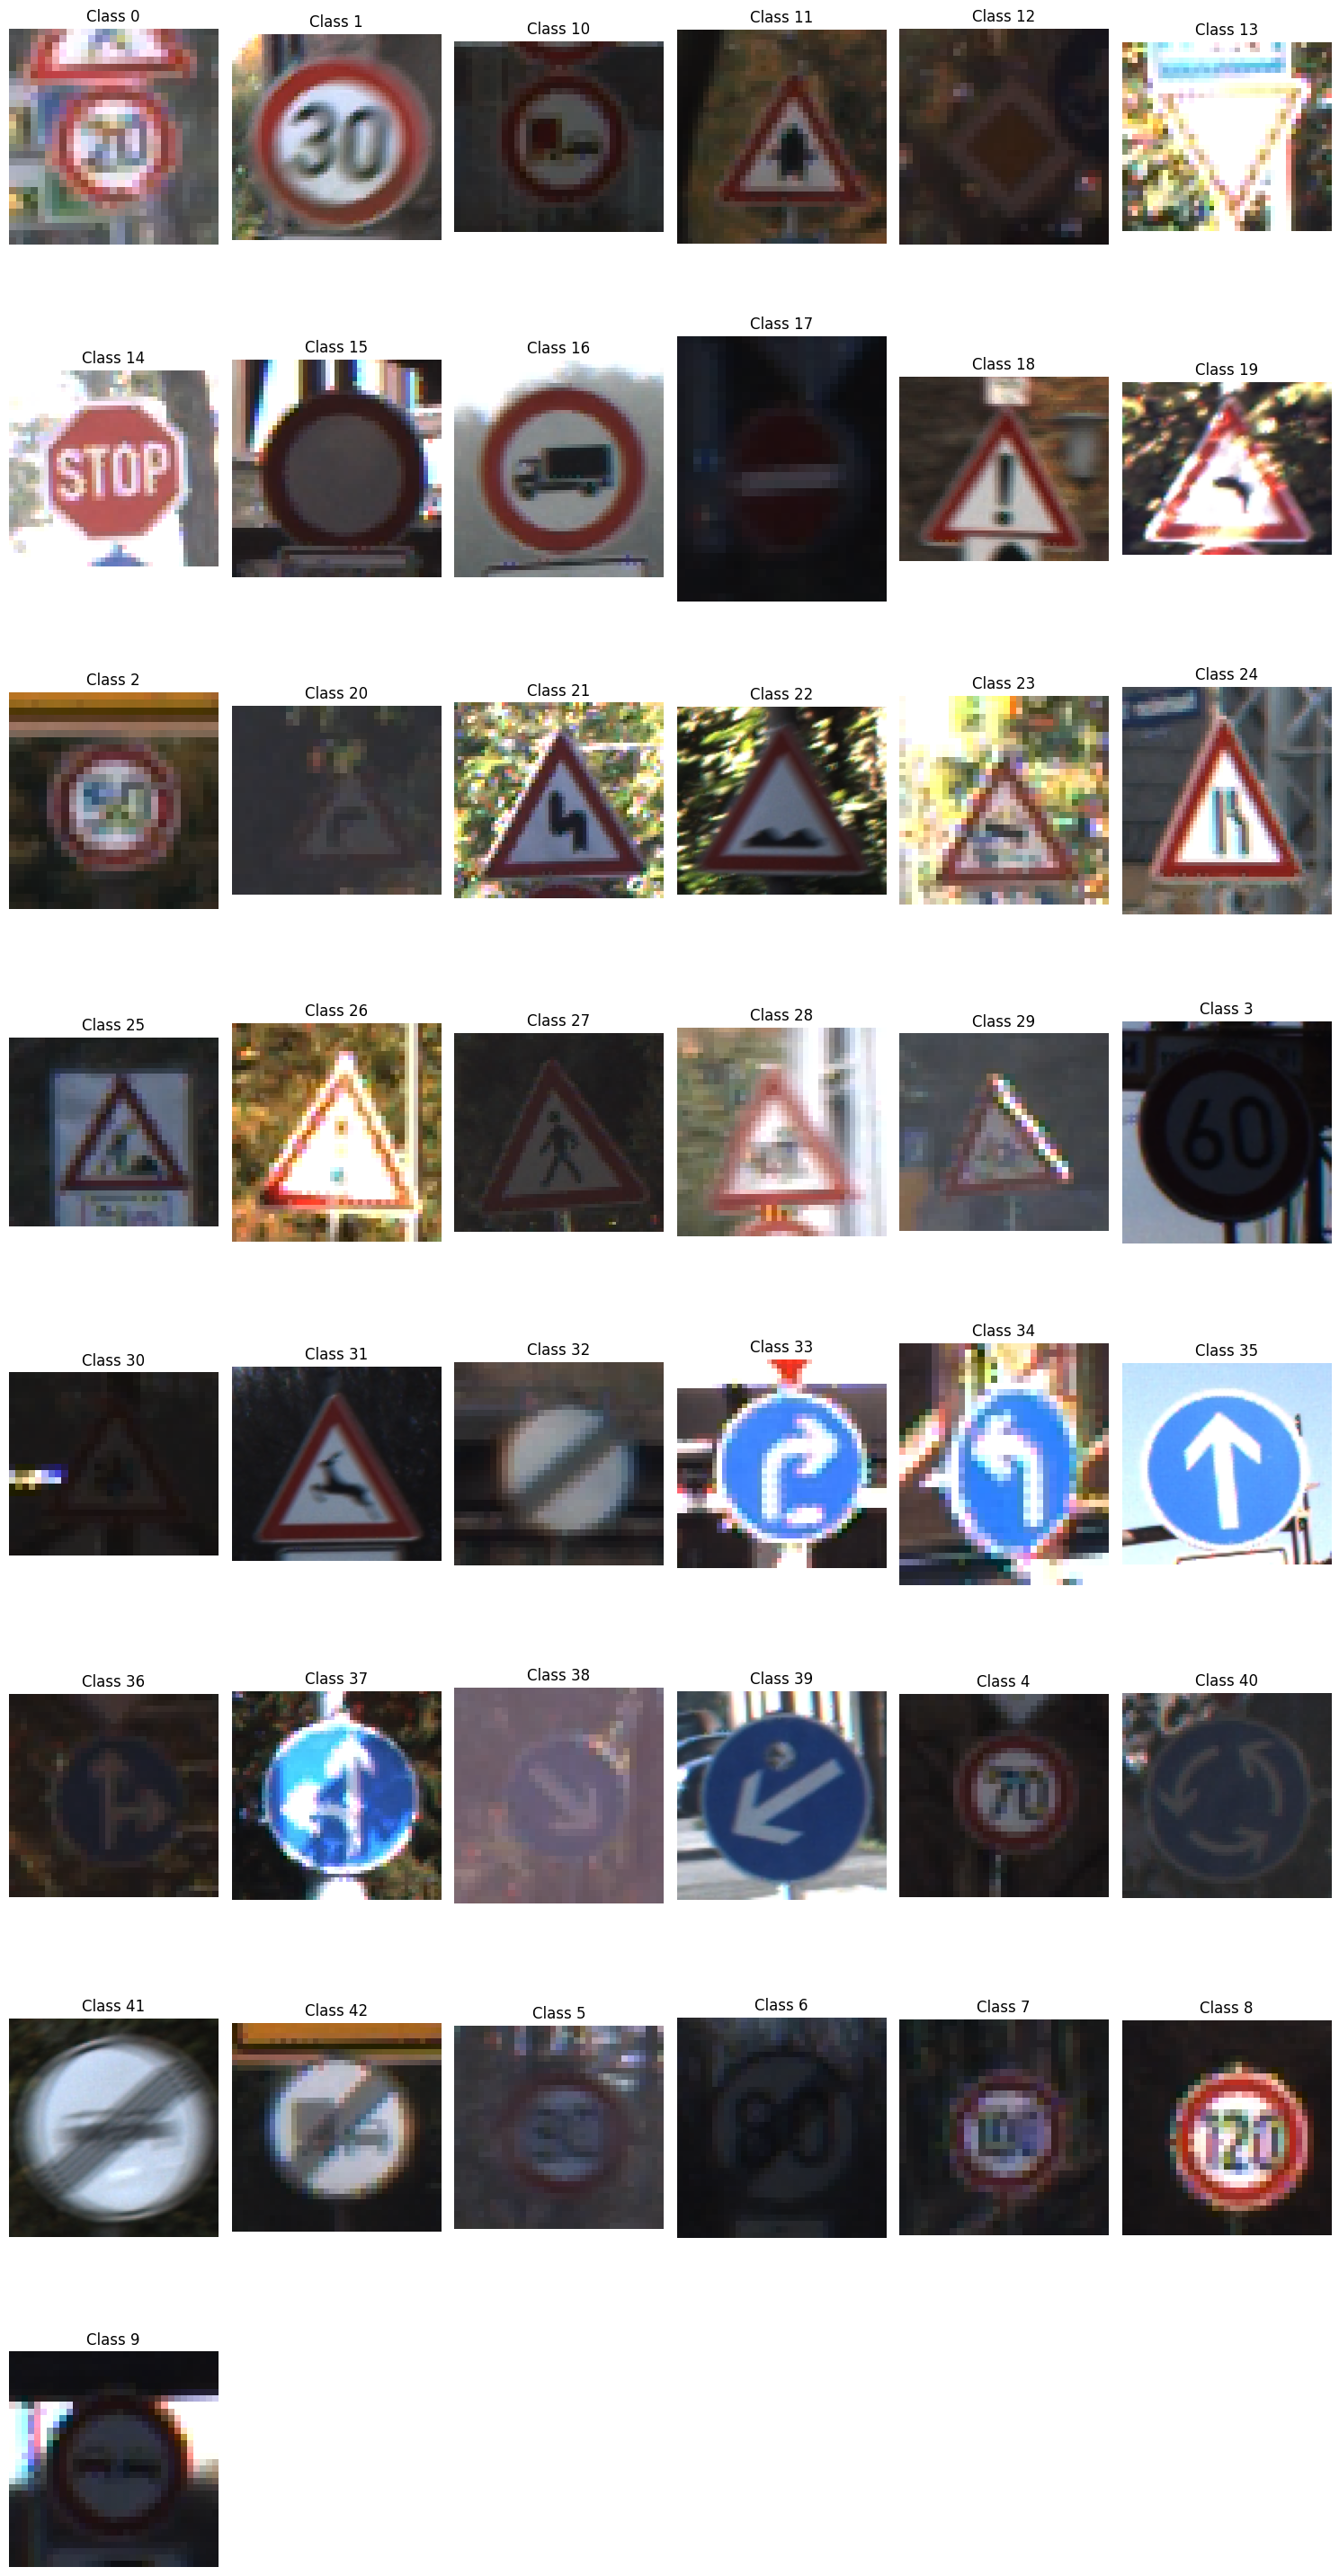

In [ ]:
# Sample image from each class
plt.figure(figsize = (15,30))
for i, cls in enumerate(classes):

  class_path = os.path.join(dataset_path, cls)

  img_name = os.listdir(class_path)[0]
  img_path = os.path.join(class_path, img_name)

  image = cv2.imread(img_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  plt.subplot(8,6, i+1)
  plt.imshow(image)
  plt.title(f"Class {cls}")
  plt.axis("off")
plt.tight_layout()
plt.show()


**Bivariate Analysis**

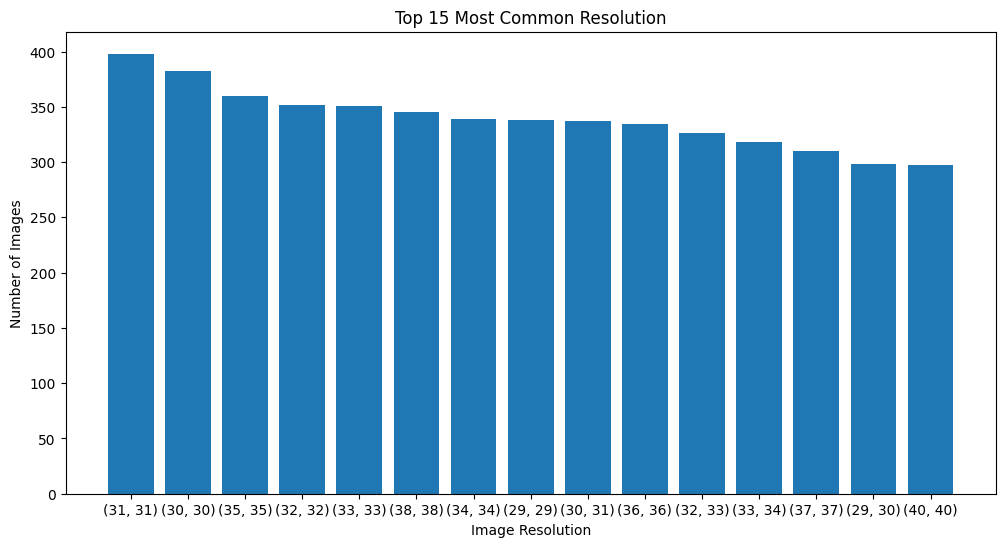

In [ ]:
# Image Resolution
from collections import Counter

# create list to store image resolution
resolutions = []

for image in images:

  height, width = image.shape[:2]
  resolutions.append((width, height))

# resolution counts
resolution_counts = Counter(resolutions)

# top 15 resolution
top_resolutions = resolution_counts.most_common(15)

# separate resolution and their counts
resolution_names = [str(res) for res, count in top_resolutions]
counts = [count for res, count in top_resolutions]

# plot
plt.figure(figsize = (12,6))
plt.bar(resolution_names, counts)
plt.title("Top 15 Most Common Resolution")
plt.xlabel("Image Resolution")
plt.ylabel("Number of Images")
plt.show()



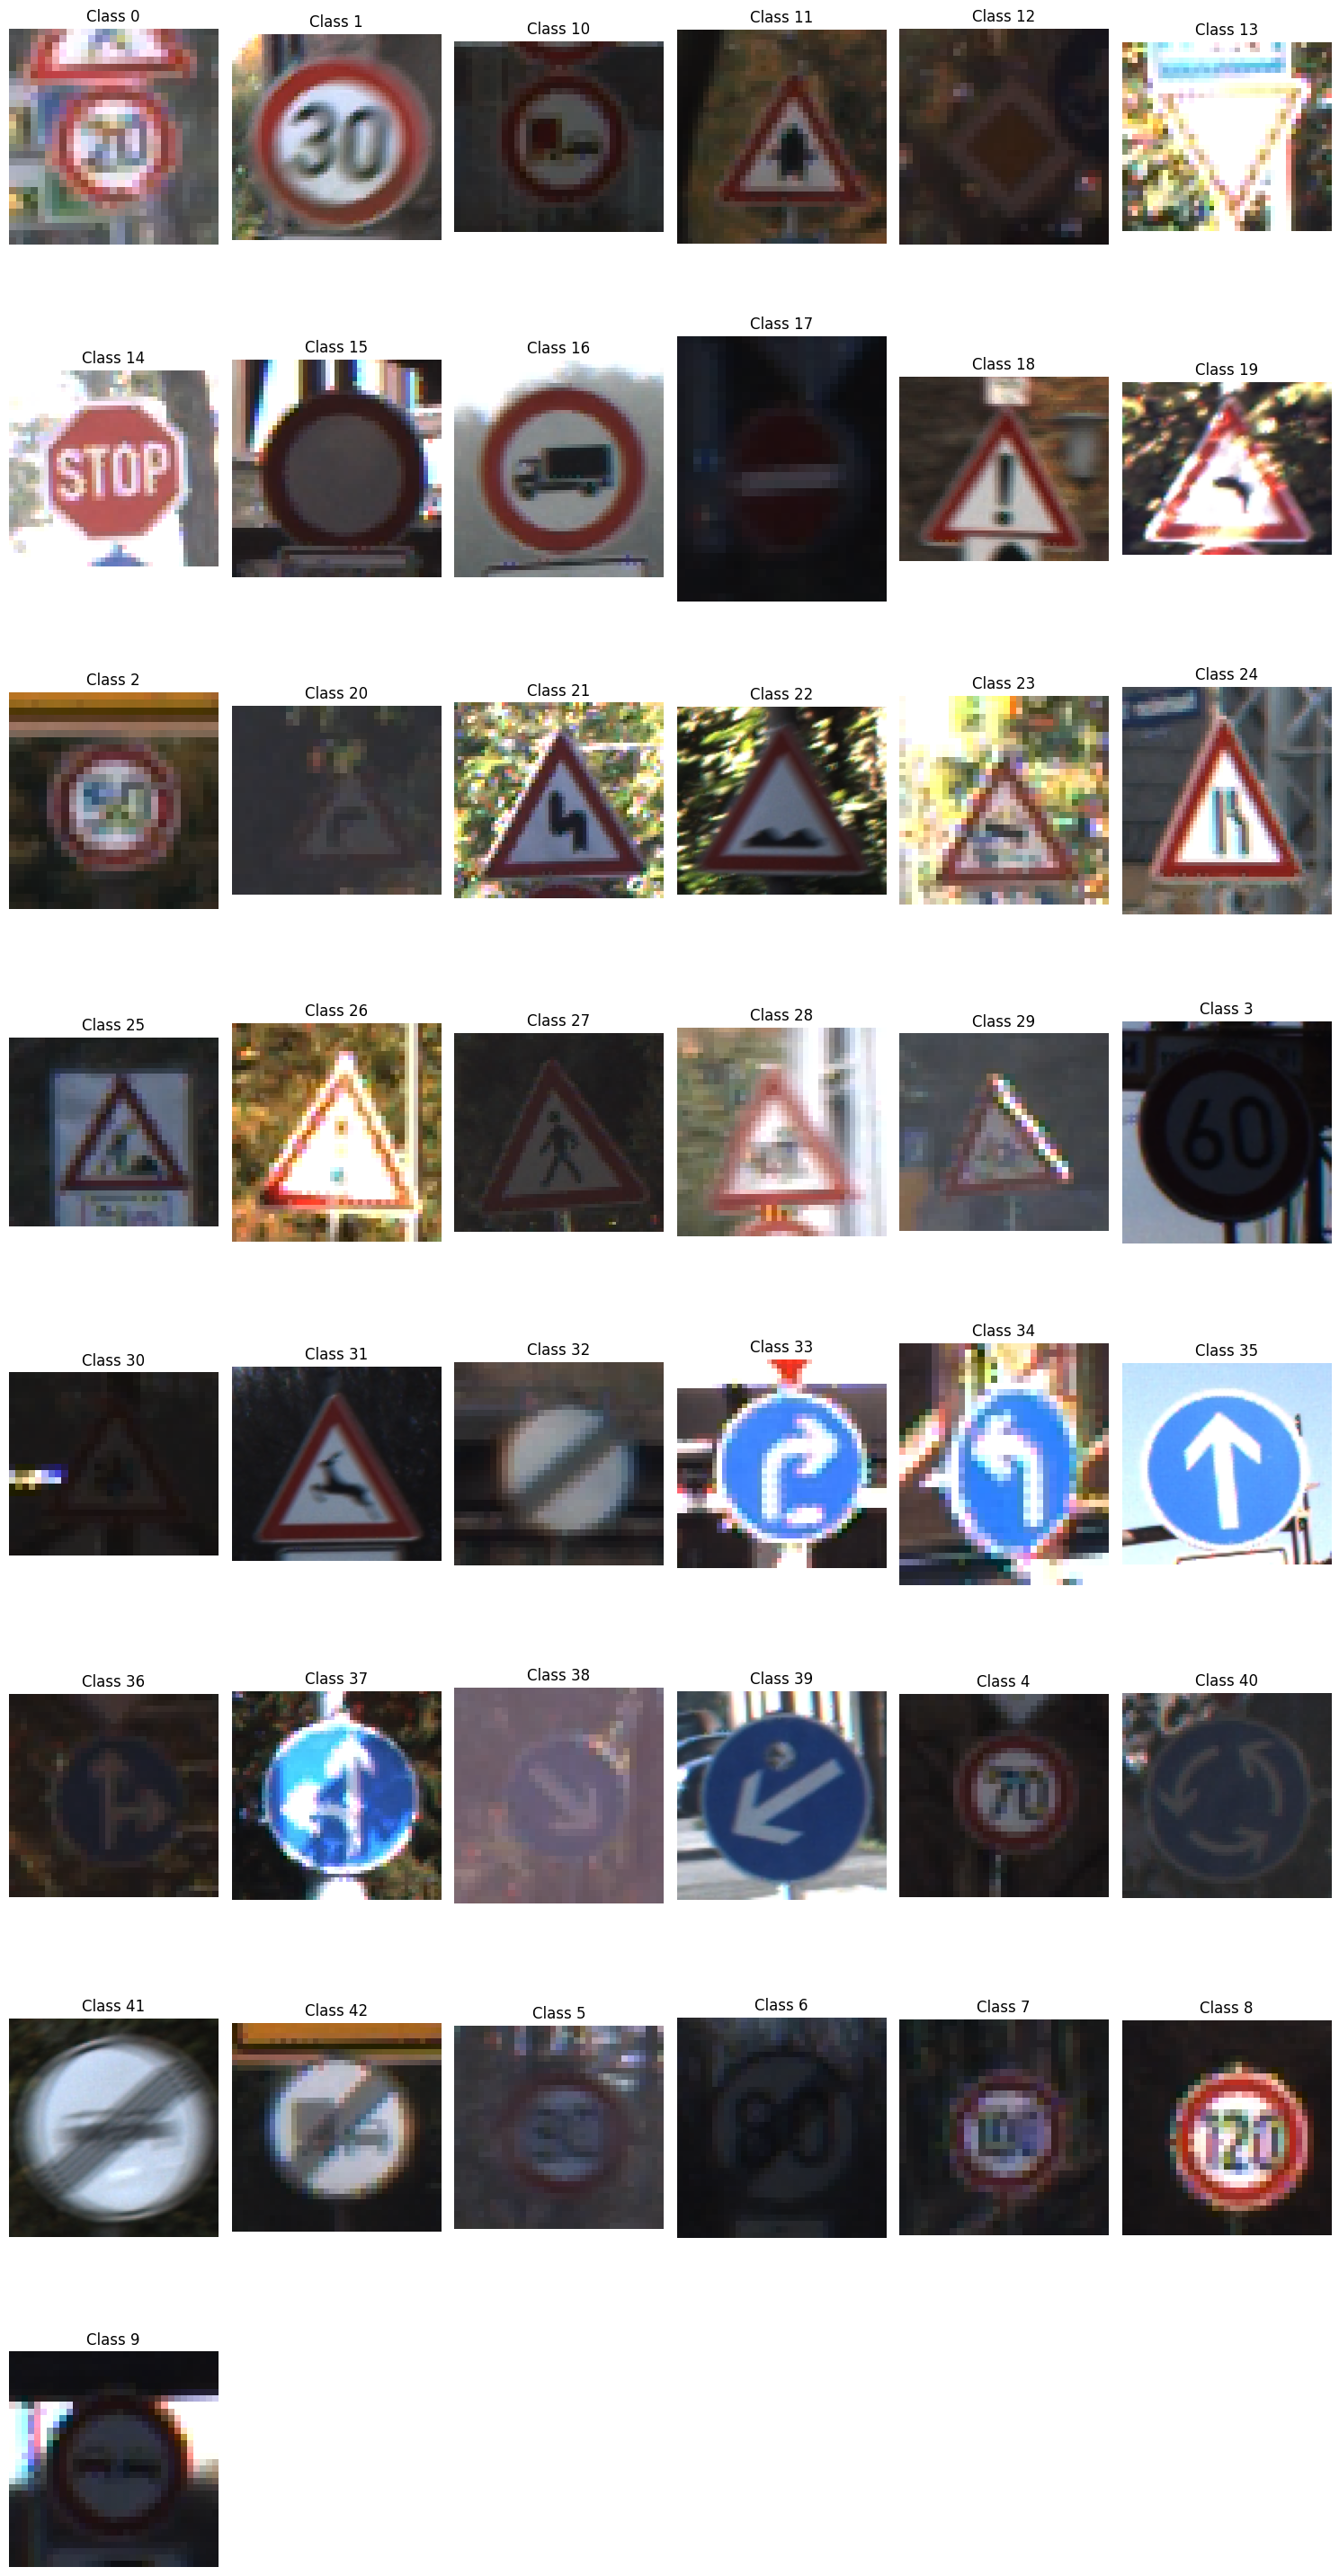

In [ ]:
# Image grouped by Classes

classes = sorted(classes)

plt.figure(figsize = (15,30))
for i, cls in enumerate(classes):

  class_path = os.path.join(dataset_path, cls)

  img_name = os.listdir(class_path)[0]
  img_path = os.path.join(class_path, img_name)

  image = cv2.imread(img_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  plt.subplot(8,6, i+1)
  plt.imshow(image)
  plt.title(f"Class {cls}")
  plt.axis("off")
plt.tight_layout()
plt.show()


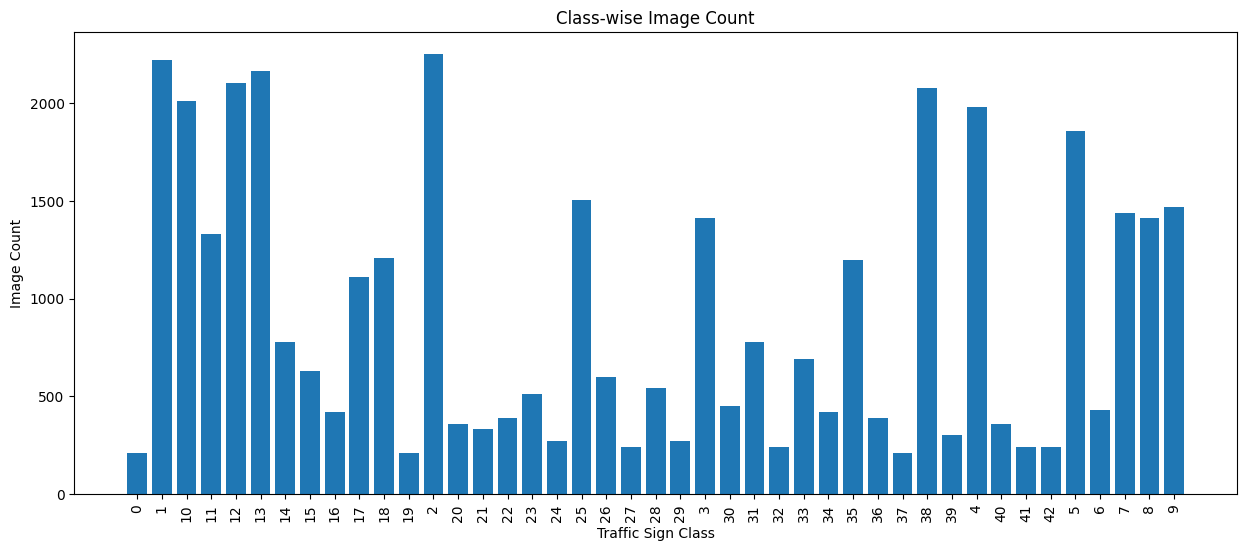

In [ ]:
# Class-wise Image Count with Percentage

class_df = pd.DataFrame({
    "Class": sorted(class_counts.keys()),
    "Image_Count": [
        class_counts[i] for i in sorted(class_counts.keys())
    ]
})

class_df["Percentage"] = (class_df["Image_Count"] / class_df["Image_Count"].sum()) * 100

# plot
plt.figure(figsize=(15, 6))

plt.bar(class_df["Class"].astype(str),class_df["Image_Count"])
plt.xlabel("Traffic Sign Class")
plt.ylabel("Image Count")
plt.title("Class-wise Image Count")
plt.xticks(rotation=90)
plt.show()

# **Image Preprocessing**

In [ ]:
# Remove corrupted images

valid_images = []
valid_labels = []
corrupted_count = 0

for image, label in zip(images, labels):

  if image is not None and image.size > 0:
    valid_images.append(image)
    valid_labels.append(label)
  else:
    corrupted_count += 1

print("Total images:", len(images))
print("Valid images:", len(valid_images))
print("Corrupted images:", corrupted_count)



Total images: 39262
Valid images: 39262
Corrupted images: 0


There are no corrupted images in the dataset.

In [ ]:
# Resize images

img_size = 32

resized_images = []

for image in images:
  resized = cv2.resize(image, (img_size, img_size))
  resized_images.append(resized)

resized_images = np.array(resized_images)
print("Resized images shape:", resized_images.shape)

Resized images shape: (39262, 32, 32, 3)


In [ ]:
# Convert Color Space
gray_images = []

for image in resized_images:
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  gray_images.append(gray)

gray_images = np.array(gray_images)

print("Grayscale images shape:", gray_images.shape)

Grayscale images shape: (39262, 32, 32)


In [ ]:
# Normalize pixel values
normalized_images = gray_images.astype("float32") / 255.0

print("Minimum Pixel Value:", normalized_images.min())
print("Maximum Pixel Value:", normalized_images.max())

Minimum Pixel Value: 0.011764706
Maximum Pixel Value: 1.0


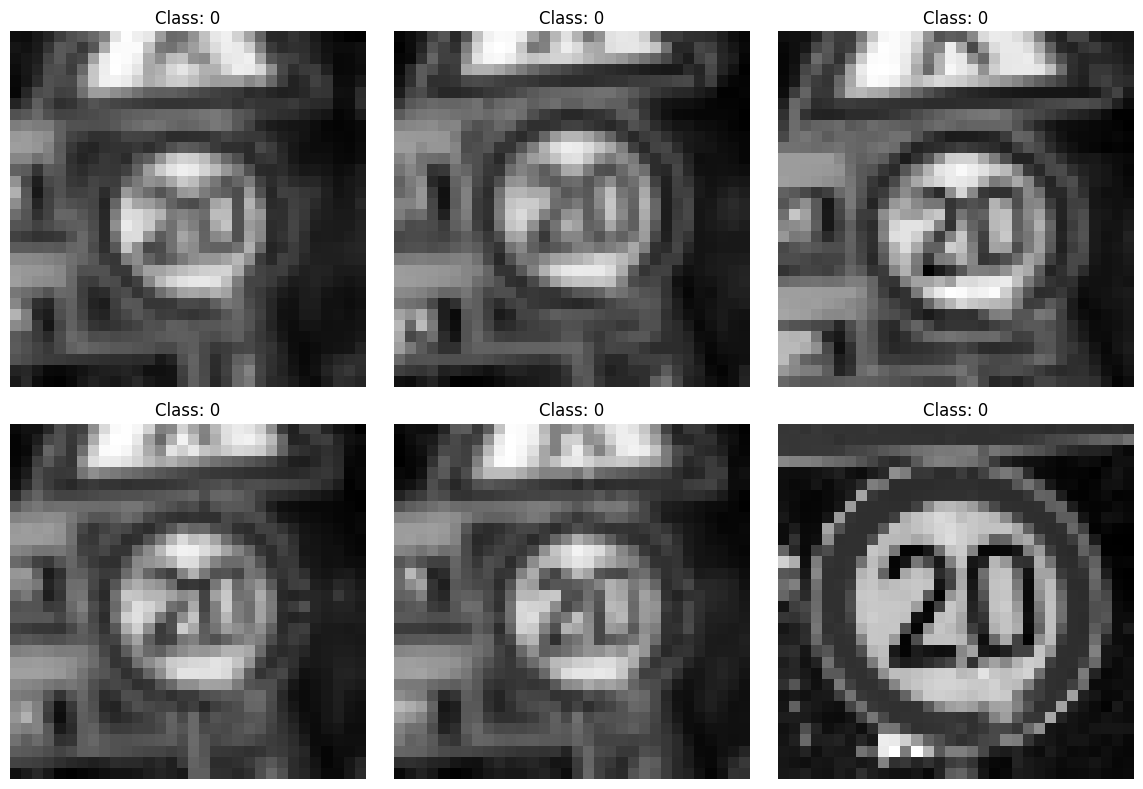

In [ ]:
# visualize preprocessed images

plt.figure(figsize = (12,8))

for i in range(6):
  plt.subplot(2, 3, i + 1)
  plt.imshow(normalized_images[i], cmap = "gray")
  plt.title(f"Class: {labels[i]}")
  plt.axis("off")
  plt.tight_layout()

**Observation**

- The images were successfully resized to a consistent 32 × 32 pixels.
- Converting the images to grayscale reduced complexity while preserving important sign shapes and edges.
- Pixel normalization brought the values to a common range, making the images suitable for further processing.
- No corrupted or unreadable images were found in the dataset.


# **Feature Extraction**

Extract image features using
- HOG(Histogram of Oriented Gradients)

In [ ]:
!pip install opencv-python


In [ ]:
from skimage.feature import hog
import numpy as np

# Store HOG features
features = []

# Extract HOG features from each image
for image in gray_images:

    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    features.append(hog_features)

# Convert to NumPy array
features = np.array(features)

print("HOG Features Shape:", features.shape)

HOG Features Shape: (39262, 324)


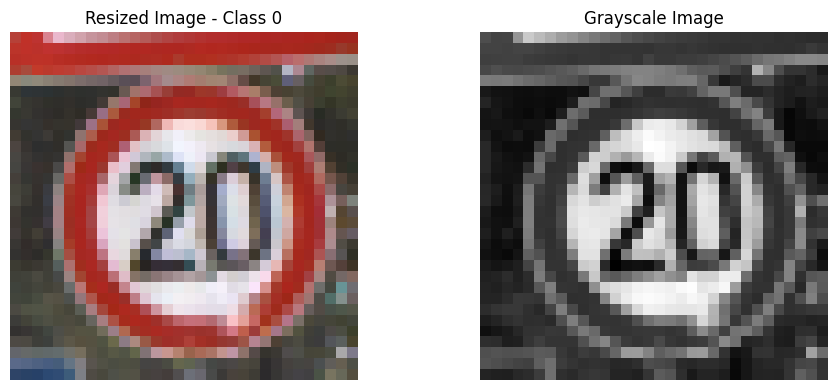

In [ ]:
# Displaying Resized and Grayscale Image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_images[6], cv2.COLOR_BGR2RGB))
plt.title(f"Resized Image - Class {labels[6]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_images[6], cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

# Adjust spacing
plt.tight_layout()
plt.show()

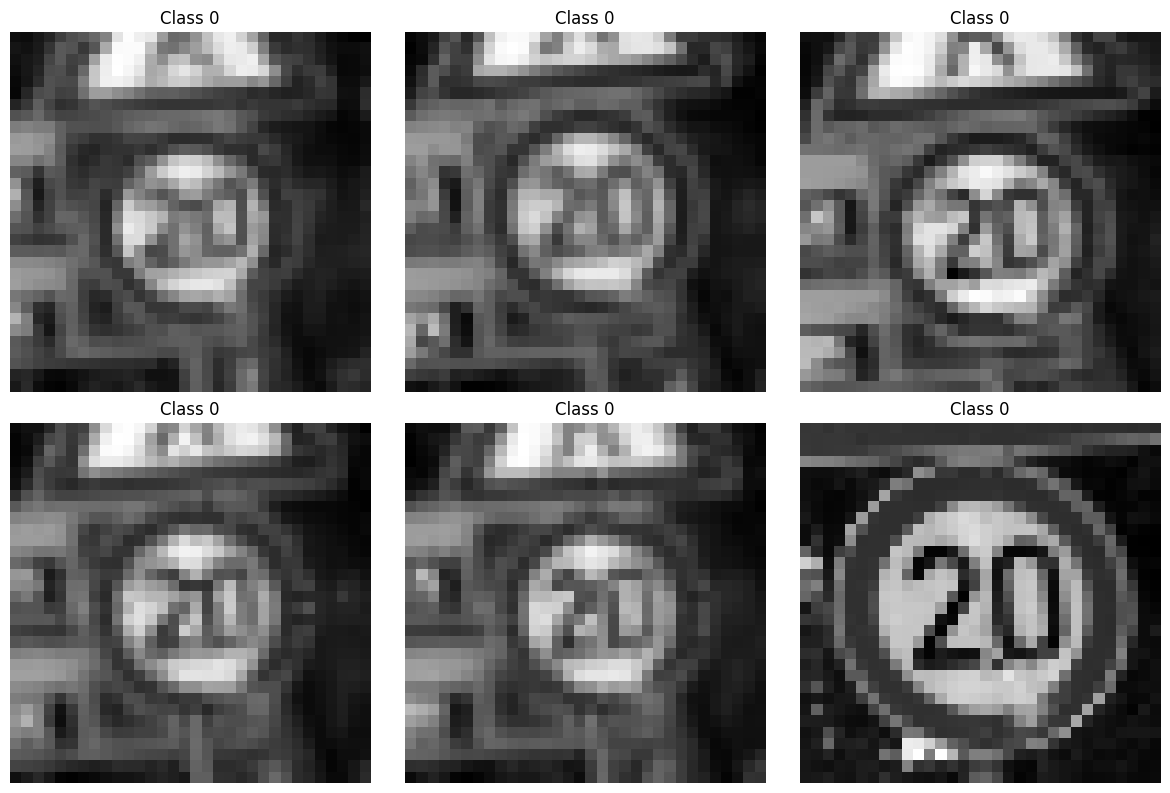

In [ ]:
# Display first 6 grayscale images
plt.figure(figsize=(12, 8))

for i in range(6):

    plt.subplot(2, 3, i + 1)
    plt.imshow(gray_images[i], cmap="gray")
    plt.title(f"Class {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Observations**

- HOG (Histogram of Oriented Gradients) was used to extract important edge, shape, and contour information from the traffic sign images.
- Each 32 × 32 grayscale image was converted into a numerical feature vector.
- The selected HOG parameters generated 324 features per image.
- HOG features reduced the raw image data while preserving important visual patterns needed for machine learning classification models.

# **Input-Output Separation**

In [ ]:
# input image features
X = features
# class labels
y = np.array(labels)

print("Input Image Features(X) Shape:", X.shape)
print("Target Labels(y) Shape:", y.shape)

Input Image Features(X) Shape: (39262, 324)
Target Labels(y) Shape: (39262,)


In [ ]:
print("Total Images:", X.shape[0])
print("Number of Features per Image:", X.shape[1])
print("Sample Class Label:", y[0])

Total Images: 39262
Number of Features per Image: 324
Sample Class Label: 0


In [ ]:
#Check the data type
print("X Data Type:", X.dtype)
print("y Data Type:", y.dtype)
print()
# check for missing values
print("X contains missing values:", np.isnan(X).any())
print("y contains missing values:", pd.isnull(y).any())

X Data Type: float64
y Data Type: int64

X contains missing values: False
y contains missing values: False


In [ ]:
print("\nFirst 5 features vectors:", X[:5])

print("\nFirst 5 labels:", y[:5])


First 5 features vectors: [[0.26216132 0.26216132 0.09879397 ... 0.01831246 0.05118833 0.16922129]
 [0.27309247 0.14803341 0.10938132 ... 0.03898095 0.20991351 0.18193737]
 [0.23154199 0.30181326 0.12082384 ... 0.01831027 0.20458016 0.12424303]
 [0.27589947 0.27589947 0.08701695 ... 0.02209554 0.19530571 0.21238115]
 [0.22196019 0.26888917 0.02460937 ... 0.01782688 0.09394081 0.24785596]]

First 5 labels: [0 0 0 0 0]


# **Train-Test Split**

In [ ]:
# Split the dataset into Training set(80%) and Testing set(20%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify = y)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (31409, 324)
X_test Shape: (7853, 324)
y_train Shape: (31409,)
y_test Shape: (7853,)


In [ ]:
print("First 20 labels:")
print(y[:20])

print("\nUnique labels:")
print(np.unique(y))

print("\nLabel data type:")
print(type(y[0]))

First 20 labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Unique labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]

Label data type:
<class 'numpy.int64'>


# **Model Building**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report

**Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter= 1000, random_state= 42)
# train the model
lr.fit(X_train, y_train)

# predict the model
lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression:")
print("Accuracy:", lr_accuracy)

print("\nModel classes:")
print(lr.classes_)

Logistic Regression:
Accuracy: 0.8867948554692474

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(random_state= 42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree:")
print("Accuracy:", dt_accuracy)

print("\nModel classes:")
print(dt.classes_)

Decision Tree:
Accuracy: 0.6668788997835222

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


**Random Forest**

In [ ]:
rf = RandomForestClassifier(random_state= 42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest:")
print("Accuracy:", rf_accuracy)

print("\nModel classes:")
print(rf.classes_)

Random Forest:
Accuracy: 0.8833566789761874

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


**K-Nearest Neighbors**

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN:")
print("Accuracy:", knn_accuracy)

print("\nModel classes:")
print(knn.classes_)

KNN:
Accuracy: 0.960524640264867

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


**Gaussian Naive Bayes**

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes:")
print("Accuracy:", nb_accuracy)

print("\nModel classes:")
print(nb.classes_)

Naive Bayes:
Accuracy: 0.7389532662676684

Model classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [ ]:
print("Logistic Regression: {:.2f}%".format(lr_accuracy * 100))
print("Decision Tree: {:.2f}%".format(dt_accuracy * 100))
print("Random Forest: {:.2f}%".format(rf_accuracy * 100))
print("KNN: {:.2f}%".format(knn_accuracy * 100))
print("Naive Bayes: {:.2f}%".format(nb_accuracy * 100))

Logistic Regression: 88.68%
Decision Tree: 66.69%
Random Forest: 88.34%
KNN: 96.05%
Naive Bayes: 73.90%


# **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# tuning KNN model
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(estimator= knn,
                           param_grid = param_grid,
                           cv =3,
                           scoring = 'accuracy',
                           n_jobs = -1,
                           verbose = 1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.9591518708575452


In [ ]:
# evaluate tuned Knn
best_knn = grid_search.best_estimator_

knn_tuned_pred = best_knn.predict(X_test)

knn_tuned_accuracy = accuracy_score(y_test, knn_tuned_pred)

print("Tuned KNN:")
print("Accuracy:{:.2f}%".format(knn_tuned_accuracy * 100))

Tuned KNN:
Accuracy:97.30%


# **Model Evaluation**

In [ ]:
# import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, knn_tuned_pred)
precision = precision_score(y_test, knn_tuned_pred, average = 'weighted')
recall = recall_score(y_test, knn_tuned_pred, average= 'weighted')
f1 = f1_score(y_test, knn_tuned_pred, average = 'weighted')

print("KNN Model Evaluation")
print("-" * 60)
print(f"Accuracy :  {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall :    {recall:.2f}")
print(f"F1_Score :  {f1:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, knn_tuned_pred))

KNN Model Evaluation
------------------------------------------------------------
Accuracy :  0.97
Precision : 0.97
Recall :    0.97
F1_Score :  0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.96      0.95      0.96       444
           2       0.94      0.93      0.94       451
           3       0.99      0.91      0.95       282
           4       0.97      0.98      0.97       396
           5       0.88      0.95      0.91       372
           6       1.00      0.99      0.99        86
           7       0.95      0.91      0.93       288
           8       0.93      0.97      0.95       282
           9       0.98      0.99      0.98       294
          10       0.99      0.99      0.99       402
          11       0.97      0.99      0.98       266
          12       1.00      1.00      1.00       421
          13       1.00      1.00      1.00       434
          14   

<Figure size 1500x1500 with 0 Axes>

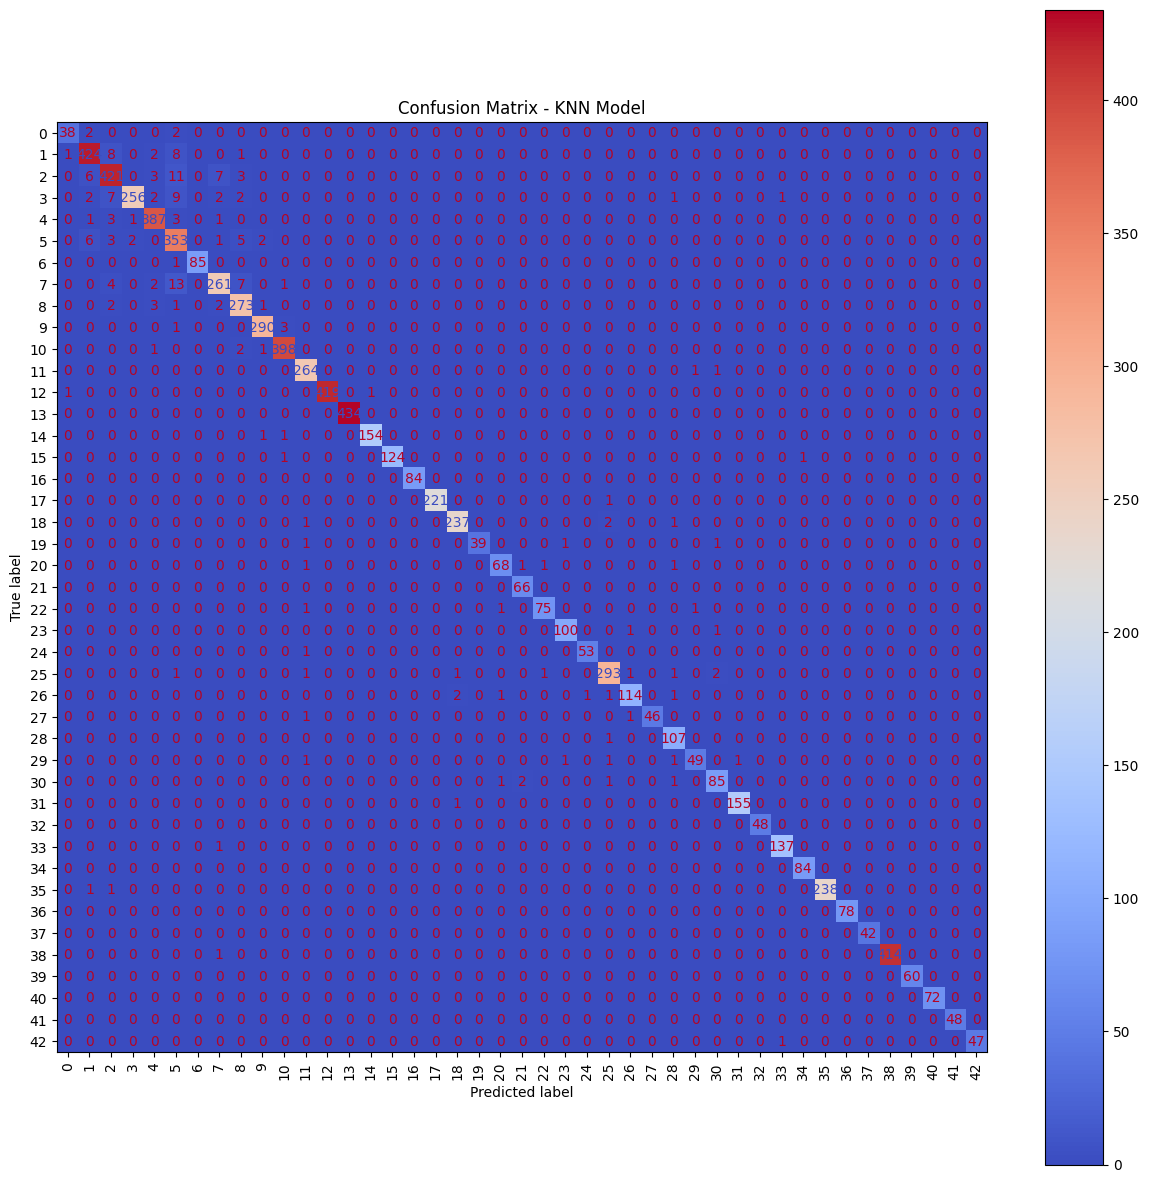

In [ ]:
import seaborn as sns
# confusion matrix
cm = confusion_matrix(y_test, knn_tuned_pred)

plt.figure(figsize = (15,15))
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, xticks_rotation=90, cmap = 'coolwarm')
plt.title("Confusion Matrix - KNN Model")
plt.show()

# **Project Workflow & Conclusion**

The project developed a machine learning-based Traffic Sign Recognition System using 39,262 images across 43 classes. After exploratory data analysis, images were checked for corruption, resized to 32×32 pixels, converted to grayscale, and normalized. HOG (Histogram of Oriented Gradients) extracted edge and shape features, producing 324 numerical features per image.

The dataset was split into 80% training and 20% testing using stratified sampling to ensure balanced representation. Multiple machine learning models — Logistic Regression, Decision Tree, Random Forest, KNN, and Naive Bayes — were trained and evaluated with Accuracy, Precision, Recall, and F1-Score. Random Forest, tuned with GridSearchCV, achieved the best performance.

The final model was evaluated with a Classification Report and Confusion Matrix, then saved using Joblib for deployment. Integration with OpenCV and Streamlit enables interactive recognition.

This project demonstrates the effective use of Computer Vision and Machine Learning for traffic sign classification. The trained model provides a foundation for intelligent transportation and driver-assistance systems and can be extended to real-time recognition using a camera.

# **Model Saving**

In [ ]:
import joblib

# get the best tuned KNN model
best_knn_model = grid_search.best_estimator_

# save the trained KNN model
joblib.dump(best_knn_model, "traffic_sign_knn_model.pkl")

print("KNN model saved successfully")

KNN model saved successfully


In [ ]:
# create class names (sign names)
class_names = {
    0: "Speed limit (20 km/h)",
    1: "Speed limit (30 km/h)",
    2: "Speed limit (50 km/h)",
    3: "Speed limit (60 km/h)",
    4: "Speed limit (70 km/h)",
    5: "Speed limit (80 km/h)",
    6: "End of speed limit (80 km/h)",
    7: "Speed limit (100 km/h)",
    8: "Speed limit (120 km/h)",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals ahead",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing for vehicles over 3.5 tons"
}

# save class names
joblib.dump(class_names, "class_names.pkl")
print("Class names saved successfully!")

Class names saved successfully!


# **Model Loading**

In [ ]:
# load the model
loaded_model = joblib.load("traffic_sign_knn_model.pkl")

print("Trained KNN model loaded successfully")

Trained KNN model loaded successfully


In [ ]:
# verify the loaded model
print(type(loaded_model))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


In [ ]:
class_names = joblib.load("class_names.pkl")

print("Number of classes:", len(classes))

Number of classes: 43


In [ ]:
sample_prediction = int(loaded_model.predict(X_test[:1])[0])
actual_class = int(y_test[0])

print("Predicted Class ID:", sample_prediction)
print("Predicted Class:", class_names[sample_prediction])

print("Actual Class ID:", actual_class)
print("Actual Class:", class_names[actual_class])

Predicted Class ID: 21
Predicted Class: Double curve
Actual Class ID: 21
Actual Class: Double curve
